# Zooma cross-check: is the assigned ontology correct?

The deterministic trace-back cascade's non-exact strategies (normalized, case-insensitive, ontology synonym, fuzzy, bag of words) find evidence text that isn't a literal match to the value they end up assigning an ontology term to -- that's exactly where a wrong term, or a wrong *ontology*, is most likely to slip in.
This notebook sends every such case's literal evidence phrase to EBI's Zooma text-annotation service, independently of the pipeline's own assumed ontology, and checks whether the pipeline's assigned term agrees with what Zooma proposes.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("zooma_cross_check.ipynb")

### Table of contents


[Zooma cross-check: is the assigned ontology correct?](#Zooma-cross-check:-is-the-assigned-ontology-correct?)
- [Setup](#Setup)
- [Methodology](#Methodology)
- [How often did Zooma find anything at all for the evidence phrase?](#How-often-did-Zooma-find-anything-at-all-for-the-evidence-phrase?)
- [Does the pipeline's assigned term agree with Zooma?](#Does-the-pipeline's-assigned-term-agree-with-Zooma?)
- [Agreement rate by target field](#Agreement-rate-by-target-field)
- [Agreement rate by matching strategy](#Agreement-rate-by-matching-strategy)
- [When they disagree, which ontology does Zooma reach for instead?](#When-they-disagree,-which-ontology-does-Zooma-reach-for-instead?)
- [Example disagreements](#Example-disagreements)
- [Limitations](#Limitations)
- [Summary](#Summary)

## Setup

In [2]:
# IMPORTS
import matplotlib.pyplot as plt
import pandas as pd

from bs_entries import MATCH_STRATEGIES
from notebook_utils import display_with_nested_tables, md, plot_heatmap_table
from paths import ZOOMA_CASE_UNIVERSE_PARQUET
from zooma_scoring import (
    CONFIDENCE_THRESHOLD,
    canonical_term,
    confident_candidates,
    exact_match_rank,
    load_zooma_results,
    score_all_cases,
)

/workspace/BH26/BH26_BioSample_curation/.conda_env/lib/python3.12/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# LOAD CASE UNIVERSE AND SCORE EVERY CASE AGAINST ITS ZOOMA RESULT
cases = pd.read_parquet(ZOOMA_CASE_UNIVERSE_PARQUET)
scored = score_all_cases()

# NCBIGene and Cellosaurus (CVCL) assigned terms can never meaningfully agree with a Zooma
# candidate (neither is an OLS-indexed ontology Zooma searches) -- when Zooma does return
# something for their evidence phrase, it's a same-text coincidence with an unrelated
# ontology, not a real disagreement. Excluded from every agreement-rate computation below;
# kept visible in the coverage table and by-field breakdown, where they show up honestly as
# consistently near-zero.
UNCHECKABLE_PREFIXES = {"NCBIGENE", "CVCL"}
scored["assigned_ontology"] = scored["assigned_term_id"].map(
    lambda x: (canonical_term(x) or (None,))[0]
)
scored["is_checkable"] = ~scored["assigned_ontology"].isin(UNCHECKABLE_PREFIXES)

# The pipeline's own candidate generation was restricted per field to exactly one local
# ontology file (config/select-config-hg38.json), so it could never propose a term from
# outside that ontology. Zooma's open search has no such restriction. Used below to build a
# same-ontology-restricted view of Zooma's candidates alongside the open-search one, so
# ranking/ontology-mismatch findings aren't confounded by Zooma simply having a larger
# candidate pool to draw from than the pipeline ever did.
TARGET_FIELD_ONTOLOGY = {
    "cell_type": "CL",
    "tissue": "UBERON",
    "disease": "MONDO",
    "drug": "CHEBI",
}


def candidate_ontology_prefixes(candidates: list[dict]) -> set[str]:
    return {
        p
        for c in candidates
        if (p := (canonical_term(c["termId"]) or (None,))[0]) is not None
    }


NON_EXACT_STRATEGIES = [s for s in MATCH_STRATEGIES if s != "exact"]
STRATEGY_ORDER = ["exact", *NON_EXACT_STRATEGIES]
VERDICT_ORDER = ["exact", "child", "xref", "different_term", "no_zooma_result"]
VERDICT_COLORS = {
    "exact": "#0b5394",
    "child": "#6da7ec",
    "xref": "#56B4E9",
    "different_term": "#D55E00",
    "no_zooma_result": "#bbbbbb",
}
VERDICT_LABELS = {
    "exact": "exact match",
    "child": "assigned term is a child of Zooma's",
    "xref": "cross-ontology equivalent (xref)",
    "different_term": "disagrees",
    "no_zooma_result": "Zooma found nothing",
}

md(
    f"Scored **{len(scored):,}** cases -- every distinct (raw evidence field, evidence phrase, assigned term), "
    f"across all **{scored['target_field'].nunique()}** target fields and all **{scored['strategy'].nunique()}** matching "
    f"strategies (`exact` included as a baseline check, see Methodology) -- against Zooma's independent text "
    f"annotation, at a **{CONFIDENCE_THRESHOLD:.0%}** minimum Zooma confidence. **{scored['is_checkable'].sum():,}** "
    f"({100 * scored['is_checkable'].mean():.1f}%) have an assigned term Zooma could plausibly agree with at all "
    "(NCBIGene/Cellosaurus terms excluded from agreement-rate sections below -- see Methodology)."
)

Scored **194,133** cases -- every distinct (raw evidence field, evidence phrase, assigned term), across all **9** target fields and all **6** matching strategies (`exact` included as a baseline check, see Methodology) -- against Zooma's independent text annotation, at a **50%** minimum Zooma confidence. **99,690** (51.4%) have an assigned term Zooma could plausibly agree with at all (NCBIGene/Cellosaurus terms excluded from agreement-rate sections below -- see Methodology).

## Methodology

**Scope.** Every row with a real assigned term, from any strategy. The cascade's non-exact strategies (`case-insensitive`, `normalized`, `ontology synonym`, `bag of words`, `fuzzy`) are the primary interest -- their evidence text isn't a literal match to the assigned value, so that's where a wrong term, or a wrong ontology, is most likely to slip in. `exact` rows are kept in too, as a baseline/validity check: their evidence text is by construction identical to the assigned value, so they aren't expected to surface new *disagreements* the way the non-exact strategies can, but including them is cheap and confirms the method itself isn't systematically biased. `not found` rows are excluded -- they have no assigned term to check.
Each row's evidence-citation arrays are exploded first (a row can cite multiple raw fields/phrases), then deduplicated on `(raw_field, raw_matched_phrase, assigned_term_id)`: the same literal phrase, in the same kind of source field, judged to support the same term, is the same test regardless of which accession it came from. This is what keeps the case universe (tens of thousands) so much smaller than the raw row count (millions) -- Zooma's answer to identical text is deterministic, so the same phrase repeated across many accessions is one case, not many. See `src/build_zooma_case_universe.py`.

**Batching.** Zooma's `annotate-text-stream` endpoint does full-text NER-style annotation, not one lookup per call, so many evidence phrases are concatenated (newline-separated) into one request and Zooma's own response tells us which candidates it found for which input text (matched back by exact segment text, since phrases are deduplicated before batching). A smoke test found latency scales gently (2,500 phrases per call ~= 6 seconds) with no throttling on rapid back-to-back calls; batches were kept well under that anyway. See `src/run_zooma_batch.py`.

**Open ontology search.** Zooma was queried without restricting it to the field's own assumed ontology (e.g. tissue rows were not restricted to UBERON) -- the point of this check is partly whether the pipeline picked the *right ontology* in the first place, which an ontology-restricted search could never reveal. The tradeoff: Zooma's candidate pool for a given phrase can then include ontologies the pipeline's own field config (`config/select-config-hg38.json`) never even searches, since each field there is restricted to exactly one local ontology file. An unrestricted pool can only ever add candidates, never remove the assigned term from contention, so it can't manufacture a false disagreement on its own -- but it can push the assigned term down in *rank*, or let an off-topic candidate become Zooma's top pick, purely because more things were in the running. The "Does txt2onto's own chosen term show up..." and "When they disagree, which ontology does Zooma reach for instead?" sections below both include a same-ontology-restricted view (`TARGET_FIELD_ONTOLOGY`) alongside the open one to separate that effect from a genuine disagreement.

**No surrounding context is given to Zooma at all.** Only the bare evidence phrase text is sent -- not the raw field name it came from, not the target field, nothing else. An early version prefixed each phrase with its field name (e.g. `"tissue: heart, left ventricle"`), but Zooma's tagger doesn't use `field:` as disambiguating context the way a prompt to an LLM would -- it's a literal text segmenter, and it split on the colon, treating the field name itself as a separate (useless) span to annotate. So the prefix was dropped entirely. This means Zooma's candidates and confidence for a given phrase are identical no matter which target field that phrase actually came from -- see Limitations below.

**Hit definition.** A case is:
- `exact` -- the assigned term is one of Zooma's (confidence-filtered) candidates outright, anywhere in the list, not just the top one.
- `child` -- the assigned term is a descendant (an `is_a` chain up to) one of Zooma's candidates.
- `xref` -- the assigned term has a declared, real-equivalence cross-reference (not a looser "related" annotation -- see caveat below) to one of Zooma's candidates.
- `different_term` -- Zooma found candidates, but none relate to the assigned term by any of the above.
- `no_zooma_result` -- Zooma found nothing at all for this evidence phrase.

**Why `child`/`xref` use live EBI OLS lookups, not this repo's local ontology files.** The RO-Crate's own local ontology files (`data/*/ontology/*.owl`) were checked directly and contain only flat label/synonym/definition data -- no `rdfs:subClassOf` or `hasDbXref` anywhere, in any of the four checkable ontologies. There is no local hierarchy to walk. The number of terms actually needing a check turned out small (a few hundred distinct assigned terms), so live, cached lookups against OLS (the same backend Zooma itself sits on) were used instead of downloading and parsing full-hierarchy ontology releases. Only CL/MONDO/UBERON/CHEBI/EFO terms are OLS-lookupable this way -- NCBIGene and Cellosaurus (CVCL) assigned terms can only ever land in `exact`/`different_term`/`no_zooma_result`. See `src/ols_client.py`.

## How often did Zooma find anything at all for the evidence phrase?

In [4]:
# ZOOMA COVERAGE (DID IT RETURN ANY CONFIDENT CANDIDATE), BY TARGET FIELD
coverage = (
    scored.assign(has_result=scored["verdict"] != "no_zooma_result")
    .groupby("target_field")
    .agg(n_cases=("case_id", "size"), pct_with_result=("has_result", "mean"))
    .assign(pct_with_result=lambda d: 100 * d["pct_with_result"])
    .sort_values("n_cases", ascending=False)
)
coverage.style.format({"n_cases": "{:,}", "pct_with_result": "{:.1f}%"})

,n_cases,pct_with_result
target_field,,
cell_line,"34,052",12.5%
cell_type,"32,588",26.4%
drug,"30,935",49.6%
knockout_gene,"25,546",19.4%
tissue,"22,280",40.7%
disease,"13,887",58.6%
overexpressed_gene,"13,105",22.5%
knockdown_gene,"11,063",22.7%
chip_antigen,"10,677",13.1%


## Does the pipeline's assigned term agree with Zooma?

In [5]:
# HEADLINE AGREEMENT RATE, CHECKABLE ONTOLOGIES ONLY -- NON-EXACT STRATEGIES (PRIMARY) VS. EXACT (BASELINE)
verdict_counts = (
    scored.loc[scored["is_checkable"], "verdict"]
    .value_counts()
    .reindex(VERDICT_ORDER, fill_value=0)
)


def agreement_summary(df: pd.DataFrame) -> tuple[int, int, int]:
    with_result = df[df["verdict"] != "no_zooma_result"]
    n_agree = with_result["verdict"].isin(["exact", "child", "xref"]).sum()
    return len(df), len(with_result), n_agree


checkable = scored[scored["is_checkable"]]
non_exact_scored = checkable[checkable["strategy"] != "exact"]
exact_scored = checkable[checkable["strategy"] == "exact"]

n_ne, n_ne_result, n_ne_agree = agreement_summary(non_exact_scored)
n_ex, n_ex_result, n_ex_agree = agreement_summary(exact_scored)

with_result = checkable[
    checkable["verdict"] != "no_zooma_result"
]  # used by later cells
n_agree = with_result["verdict"].isin(["exact", "child", "xref"]).sum()

md(
    f"Restricted to the **{checkable['is_checkable'].sum():,}** checkable-ontology cases (NCBIGene/Cellosaurus excluded -- see "
    "Methodology) throughout this section.\n\n"
    f"**Primary question -- non-exact strategies** ({n_ne:,} cases): Zooma returned a confident candidate for "
    f"**{n_ne_result:,}** ({100 * n_ne_result / n_ne:.1f}%); among those, the pipeline's assigned term agreed in "
    f"**{n_ne_agree:,}** ({100 * n_ne_agree / n_ne_result:.1f}%), leaving **{n_ne_result - n_ne_agree:,}** "
    f"({100 * (n_ne_result - n_ne_agree) / n_ne_result:.1f}%) pointing to a structurally unrelated candidate.\n\n"
    f"**Baseline check -- `exact` strategy** ({n_ex:,} cases, evidence text identical to the assigned value by "
    f"construction): Zooma returned a confident candidate for **{n_ex_result:,}** ({100 * n_ex_result / n_ex:.1f}%); "
    f"among those, agreement was **{100 * n_ex_agree / n_ex_result:.1f}%**. That's notably higher than the non-exact "
    "figure above, as expected, but still well short of ~100% -- even with zero ambiguity about which text to send, "
    "Zooma and the pipeline's own txt2onto+LLM step disagree a real fraction of the time (see the dedicated section "
    "below for a closer look at exactly where)."
)

Restricted to the **99,690** checkable-ontology cases (NCBIGene/Cellosaurus excluded -- see Methodology) throughout this section.

**Primary question -- non-exact strategies** (14,149 cases): Zooma returned a confident candidate for **6,444** (45.5%); among those, the pipeline's assigned term agreed in **4,769** (74.0%), leaving **1,675** (26.0%) pointing to a structurally unrelated candidate.

**Baseline check -- `exact` strategy** (85,541 cases, evidence text identical to the assigned value by construction): Zooma returned a confident candidate for **34,709** (40.6%); among those, agreement was **68.0%**. That's notably higher than the non-exact figure above, as expected, but still well short of ~100% -- even with zero ambiguity about which text to send, Zooma and the pipeline's own txt2onto+LLM step disagree a real fraction of the time (see the dedicated section below for a closer look at exactly where).

## Does txt2onto's own chosen term show up in Zooma's candidate list?

Upstream of this repo's trace-back cascade, the crate's actual curation pipeline used txt2onto to propose ontology-term candidates for a value, then had an LLM pick the one to keep as `assigned_term_id` -- exactly which txt2onto variant (its own lexical matcher, or the Zooma-backed one it also supports) isn't recorded in this crate's own outputs, so it can't be determined from the data alone.
What can be checked directly: for `exact`-strategy, checkable-ontology cases -- where the evidence phrase is identical to the assigned value, the cleanest case for this comparison since there's no ambiguity about which text to send -- does that same literal text, sent independently to Zooma, surface the pipeline's chosen term anywhere in its candidate list? And separately, is it specifically Zooma's own *top-ranked* candidate, or merely present further down the list?

In [6]:
# EXACT-STRATEGY, CHECKABLE-ONTOLOGY CASES: WHERE DOES THE ASSIGNED TERM SIT IN ZOOMA'S OWN CANDIDATE LIST
zooma_results = load_zooma_results()

txt2onto_check = scored[(scored["strategy"] == "exact") & scored["is_checkable"]].copy()


def _rank(row: pd.Series) -> str:
    candidates = confident_candidates(zooma_results.get(row["raw_matched_phrase"]))
    return exact_match_rank(row["assigned_term_id"], candidates)


def _rank_same_ontology(row: pd.Series) -> str:
    # Restricts Zooma's candidates to the one ontology the pipeline's own field config
    # searches, before ranking -- isolates whether open search (not a real disagreement)
    # is what pushed the assigned term out of the top spot.
    candidates = confident_candidates(zooma_results.get(row["raw_matched_phrase"]))
    expected = TARGET_FIELD_ONTOLOGY.get(row["target_field"])
    restricted = [
        c for c in candidates if (canonical_term(c["termId"]) or (None,))[0] == expected
    ]
    return exact_match_rank(row["assigned_term_id"], restricted)


txt2onto_check["match_rank"] = txt2onto_check.apply(_rank, axis=1)
txt2onto_check["match_rank_same_ontology"] = txt2onto_check.apply(
    _rank_same_ontology, axis=1
)
RANK_ORDER = ["top1", "present_not_top1", "absent", "no_zooma_result"]

rank_by_field = (
    txt2onto_check.groupby("target_field")["match_rank"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=RANK_ORDER, fill_value=0)
)
rank_by_field["n_cases"] = rank_by_field.sum(axis=1)
rank_by_field = rank_by_field.sort_values("n_cases", ascending=False)
rank_by_field.style.format({col: "{:,}" for col in [*RANK_ORDER, "n_cases"]})

match_rank,top1,present_not_top1,absent,no_zooma_result,n_cases
target_field,,,,,
drug,"1,303","7,531","5,564","14,924","29,322"
cell_type,"1,551","1,303","2,656","19,619","25,129"
tissue,"1,183","4,248","2,388","11,648","19,467"
disease,843,"4,616","1,523","4,641","11,623"


In [7]:
# FAIR-COMPARISON CHECK: DOES RESTRICTING ZOOMA TO THE PIPELINE'S OWN TARGET ONTOLOGY CHANGE THE RANK
n_checked = len(txt2onto_check)
n_top1_open = (txt2onto_check["match_rank"] == "top1").sum()
n_top1_restricted = (txt2onto_check["match_rank_same_ontology"] == "top1").sum()
n_present_open = txt2onto_check["match_rank"].isin(["top1", "present_not_top1"]).sum()
n_present_restricted = (
    txt2onto_check["match_rank_same_ontology"].isin(["top1", "present_not_top1"]).sum()
)

if n_present_open == n_present_restricted:
    presence_clause = (
        f"the present-anywhere rate is unchanged at **{100 * n_present_open / n_checked:.1f}%** in both, confirming "
        "restriction only reshuffles rank, it doesn't remove or add whether the assigned term shows up at all"
    )
else:
    presence_clause = (
        f"the present-anywhere rate moves from **{100 * n_present_open / n_checked:.1f}%** (open) to "
        f"**{100 * n_present_restricted / n_checked:.1f}%** (same-ontology only)"
    )

md(
    "Zooma was queried without restricting it to the pipeline's own per-field ontology (see Methodology), so its "
    "candidate list can include terms from ontologies the pipeline's own field config never even searches -- an "
    "unrestricted list can only ever add candidates, never remove the assigned term from contention, but it can "
    "push the assigned term down in *rank* if an unrelated-ontology candidate happens to score higher. Restricting "
    "Zooma's own candidates to just the ontology the pipeline's field config actually searches "
    "(`TARGET_FIELD_ONTOLOGY`) moves the **top-ranked-candidate** rate from "
    f"**{100 * n_top1_open / n_checked:.1f}%** (open search) to **{100 * n_top1_restricted / n_checked:.1f}%** "
    f"(same-ontology only), while {presence_clause}. The gap between the two top-1 rates is the open-search ranking "
    "effect the fair comparison needs to account for -- it is not evidence Zooma failed to find the right term."
)

Zooma was queried without restricting it to the pipeline's own per-field ontology (see Methodology), so its candidate list can include terms from ontologies the pipeline's own field config never even searches -- an unrestricted list can only ever add candidates, never remove the assigned term from contention, but it can push the assigned term down in *rank* if an unrelated-ontology candidate happens to score higher. Restricting Zooma's own candidates to just the ontology the pipeline's field config actually searches (`TARGET_FIELD_ONTOLOGY`) moves the **top-ranked-candidate** rate from **5.7%** (open search) to **24.9%** (same-ontology only), while the present-anywhere rate moves from **26.4%** (open) to **26.3%** (same-ontology only). The gap between the two top-1 rates is the open-search ranking effect the fair comparison needs to account for -- it is not evidence Zooma failed to find the right term.

In [8]:
# WHY CELLOSAURUS (CVCL) IS GROUPED WITH NCBIGENE AS "UNCHECKABLE" -- THE EVIDENCE, FROM THE FULL (UNFILTERED) exact-STRATEGY DATA
cell_line_exact = scored[
    (scored["strategy"] == "exact") & (scored["target_field"] == "cell_line")
].copy()
cell_line_exact["match_rank"] = cell_line_exact.apply(
    lambda row: exact_match_rank(
        row["assigned_term_id"],
        confident_candidates(zooma_results.get(row["raw_matched_phrase"])),
    ),
    axis=1,
)
n_cell_line_present = (
    cell_line_exact["match_rank"].isin(["top1", "present_not_top1"]).sum()
)

md(
    f"`cell_line` (Cellosaurus/CVCL) isn't an OLS-indexed ontology any more than NCBI Gene is, but that's worth "
    f"showing directly rather than assuming: of **{len(cell_line_exact):,}** `exact`-strategy cell-line cases, the "
    f"assigned Cellosaurus term appears anywhere in Zooma's candidates **{n_cell_line_present}** times -- this is "
    "the empirical basis for including it alongside NCBIGene in `UNCHECKABLE_PREFIXES` above, rather than an assumption."
)

`cell_line` (Cellosaurus/CVCL) isn't an OLS-indexed ontology any more than NCBI Gene is, but that's worth showing directly rather than assuming: of **33,471** `exact`-strategy cell-line cases, the assigned Cellosaurus term appears anywhere in Zooma's candidates **0** times -- this is the empirical basis for including it alongside NCBIGene in `UNCHECKABLE_PREFIXES` above, rather than an assumption.

In [9]:
# CELLOSAURUS (CELL_LINE) CHECK -- IS IT ACTUALLY CHECKABLE IN PRACTICE, DESPITE NOT BEING EXCLUDED UPFRONT LIKE NCBIGENE
cell_line_ranks = txt2onto_check.loc[
    txt2onto_check["target_field"] == "cell_line", "match_rank"
]
n_cell_line_present = cell_line_ranks.isin(["top1", "present_not_top1"]).sum()

md(
    f"`cell_line` (Cellosaurus/CVCL) wasn't excluded upfront the way NCBIGene was, but empirically behaves the same "
    f"way: of **{len(cell_line_ranks):,}** exact-strategy cell-line cases, the assigned Cellosaurus term appears in "
    f"Zooma's candidates **{n_cell_line_present}** times -- Cellosaurus identifiers turn out not to be meaningfully "
    "checkable this way either, not just NCBI Gene ones."
)

`cell_line` (Cellosaurus/CVCL) wasn't excluded upfront the way NCBIGene was, but empirically behaves the same way: of **0** exact-strategy cell-line cases, the assigned Cellosaurus term appears in Zooma's candidates **0** times -- Cellosaurus identifiers turn out not to be meaningfully checkable this way either, not just NCBI Gene ones.

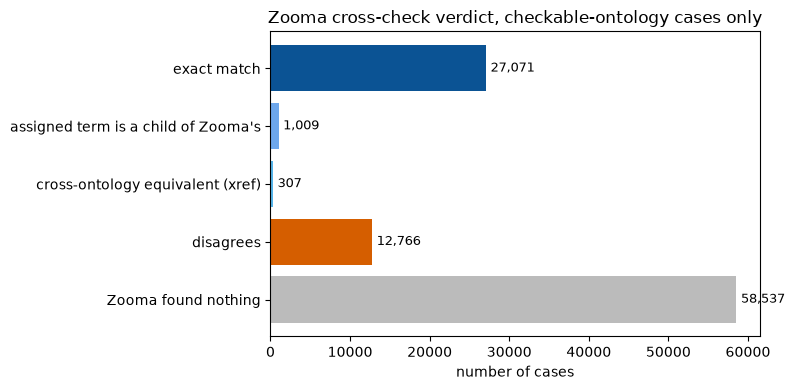

In [10]:
# OVERALL VERDICT BREAKDOWN, CHECKABLE ONTOLOGIES ONLY
def plot_verdict_breakdown(
    counts: pd.Series, figsize: tuple[float, float] = (8, 4)
) -> None:
    _fig, ax = plt.subplots(figsize=figsize)
    labels = [VERDICT_LABELS[v] for v in counts.index]
    bars = ax.barh(
        labels, counts.values, color=[VERDICT_COLORS[v] for v in counts.index]
    )
    for bar, value in zip(bars, counts.values):
        ax.text(
            bar.get_width() + counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            va="center",
            fontsize=9,
        )
    ax.set_xlabel("number of cases")
    ax.set_title("Zooma cross-check verdict, checkable-ontology cases only")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


plot_verdict_breakdown(verdict_counts)

## Agreement rate by target field

Restricted to cases Zooma returned a confident candidate for -- `no_zooma_result` cases are a coverage gap, not a disagreement, and are shown separately above. Unlike the rest of this notebook, this view deliberately keeps all 9 target fields, including the NCBIGene/Cellosaurus ones excluded elsewhere -- seeing `knockout_gene`/`knockdown_gene`/`overexpressed_gene`/`chip_antigen`/`cell_line` score consistently near-zero here, next to the real ontology fields scoring far higher, is itself the evidence for excluding them from every other section.

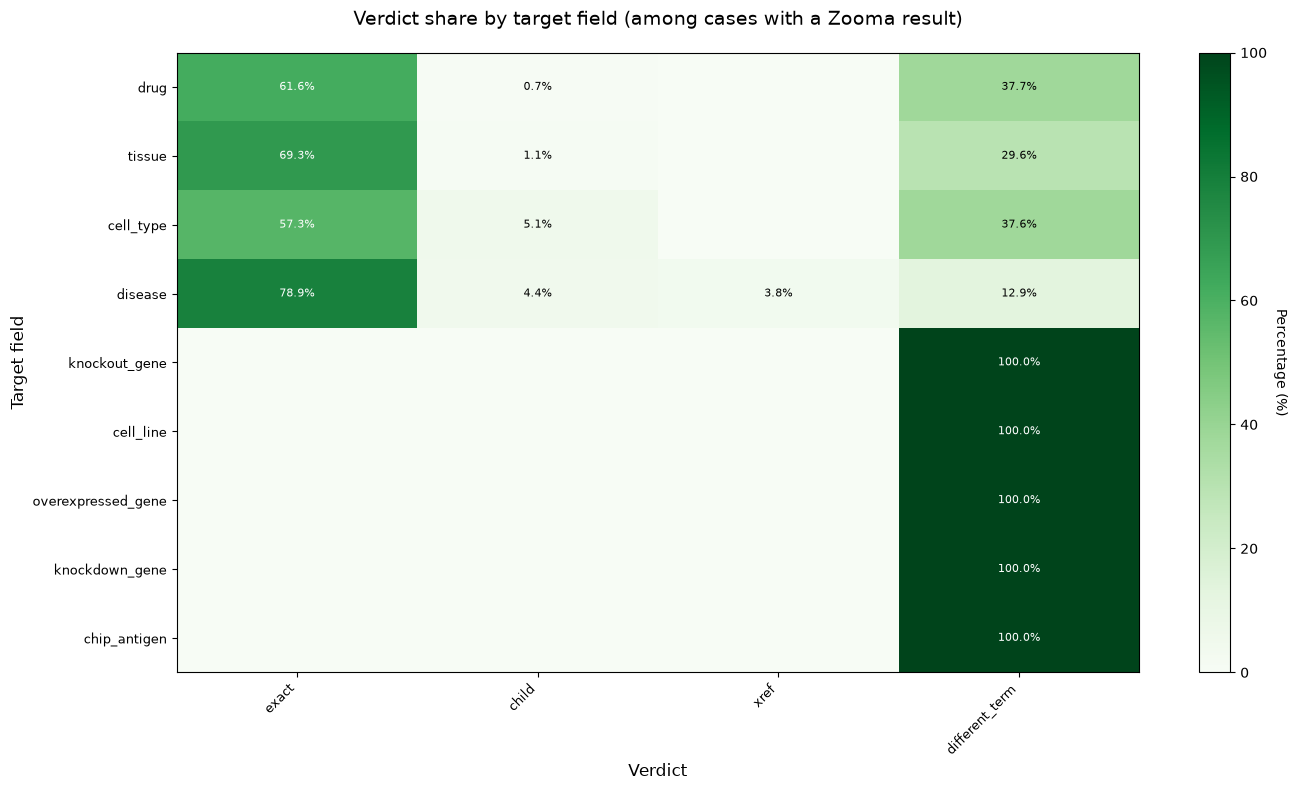

In [11]:
# AGREEMENT RATE BY TARGET FIELD, AS A HEATMAP (VERDICT SHARE AMONG CASES WITH A ZOOMA RESULT)
def verdict_share_table(
    df: pd.DataFrame, group_col: str, verdict_subset: list[str]
) -> pd.DataFrame:
    with_result = df[df["verdict"] != "no_zooma_result"]
    counts = with_result.groupby([group_col, "verdict"]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=verdict_subset, fill_value=0)
    order = with_result[group_col].value_counts().index
    return (100 * counts.div(counts.sum(axis=1), axis=0)).reindex(order)


by_field = verdict_share_table(
    scored, "target_field", ["exact", "child", "xref", "different_term"]
)
plot_heatmap_table(
    by_field,
    title="Verdict share by target field (among cases with a Zooma result)",
    xlabel="Verdict",
    ylabel="Target field",
)

## Agreement rate by matching strategy

This is the comparison the notebook opened with: do the cascade's different non-exact strategies for finding evidence text carry different risk of landing on the wrong ontology term? `exact` is included as the leftmost reference column. Checkable-ontology cases only, same restriction as the headline numbers above -- some strategies have very few checkable cases with a Zooma result (see the case-count table below the heatmap), so their rates should be read with that in mind.

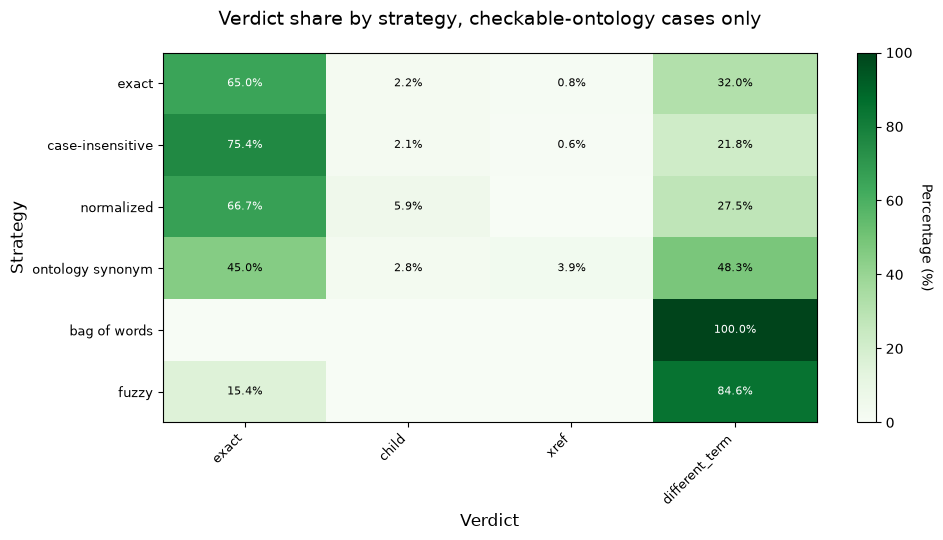

In [12]:
# AGREEMENT RATE BY STRATEGY, EXACT INCLUDED AS THE REFERENCE COLUMN -- CHECKABLE ONTOLOGIES ONLY
by_strategy = verdict_share_table(
    checkable, "strategy", ["exact", "child", "xref", "different_term"]
).reindex(STRATEGY_ORDER)
plot_heatmap_table(
    by_strategy,
    title="Verdict share by strategy, checkable-ontology cases only",
    xlabel="Verdict",
    ylabel="Strategy",
    figsize=(10, 5.5),
)

In [13]:
# CASE COUNTS BEHIND THE HEATMAP ABOVE -- SOME STRATEGIES HAVE VERY FEW CHECKABLE CASES WITH A RESULT
n_with_result_by_strategy = (
    checkable[checkable["verdict"] != "no_zooma_result"]
    .groupby("strategy")
    .size()
    .reindex(STRATEGY_ORDER, fill_value=0)
    .rename("n_with_result")
)
n_with_result_by_strategy.to_frame().style.format("{:,}")

,n_with_result
strategy,
exact,"34,709"
case-insensitive,"3,307"
normalized,"2,750"
ontology synonym,360
bag of words,1
fuzzy,26


## When they disagree, which ontology does Zooma reach for instead?

The `different_term` bucket is where a wrong *ontology*, not just a wrong term, would show up: Zooma's top candidate coming from a different ontology than the one the pipeline assumed for that target field.

In [14]:
# FOR "different_term" CASES (CHECKABLE ONTOLOGIES ONLY): WHICH ONTOLOGY DOES ZOOMA'S TOP CANDIDATE COME FROM
disagreements = scored[
    scored["is_checkable"] & (scored["verdict"] == "different_term")
].copy()
disagreements["candidate_ontology"] = disagreements["top_candidate_term_id"].map(
    lambda x: (canonical_term(x) or (None,))[0]
)


def _has_same_ontology_candidate(row: pd.Series) -> bool:
    # Was there ANY confident Zooma candidate (not just the top one) in the ontology the
    # pipeline's own field config searches -- distinguishes "Zooma ranked something else
    # above the right ontology" from "Zooma's open search had nothing on-topic at all".
    expected = TARGET_FIELD_ONTOLOGY.get(row["target_field"])
    candidates = confident_candidates(zooma_results.get(row["raw_matched_phrase"]))
    return expected in candidate_ontology_prefixes(candidates)


disagreements["has_same_ontology_candidate"] = disagreements.apply(
    _has_same_ontology_candidate, axis=1
)

ontology_mismatch = (
    disagreements.groupby(["target_field", "assigned_ontology", "candidate_ontology"])
    .size()
    .rename("n_cases")
    .reset_index()
    .sort_values("n_cases", ascending=False)
)
ontology_mismatch.head(20).style.format({"n_cases": "{:,}"})

,target_field,assigned_ontology,candidate_ontology,n_cases
132,drug,CHEBI,MESH,"1,508"
140,drug,CHEBI,NCIT,"1,366"
4,cell_type,CL,BTO,"1,001"
194,tissue,UBERON,NCIT,769
144,drug,CHEBI,OMIT,699
157,drug,CHEBI,XCO,642
111,drug,CHEBI,CHEBI,449
164,tissue,UBERON,BTO,419
34,cell_type,CL,NCIT,403
107,drug,CHEBI,ARO,381


In [15]:
# SAME-ONTOLOGY DISAGREEMENT (WRONG TERM WITHIN THE RIGHT ONTOLOGY) VS. A GENUINELY DIFFERENT ONTOLOGY
same_ontology = (
    disagreements["assigned_ontology"] == disagreements["candidate_ontology"]
)
different_ontology = ~same_ontology
had_same_ontology_option = disagreements["has_same_ontology_candidate"]

n_same_ontology = same_ontology.sum()
n_diff_with_option = (different_ontology & had_same_ontology_option).sum()
n_diff_no_option = (different_ontology & ~had_same_ontology_option).sum()
n_disagreements = len(disagreements)

md(
    f"Of the **{n_disagreements:,}** `different_term` cases, Zooma's top candidate lands in the **same** ontology "
    f"the pipeline already assumed for **{n_same_ontology:,}** ({100 * n_same_ontology / n_disagreements:.1f}%) -- "
    "a wrong *term*, not a wrong *ontology*.\n\n"
    "For the rest, the top candidate is from a different ontology -- but that's only a fair 'wrong ontology' signal "
    "when Zooma actually had a same-ontology candidate available and ranked something else above it. Splitting on "
    "that (using every confident candidate for the phrase, not just the top one, via `has_same_ontology_candidate` "
    "in the table above):\n\n"
    f"- **{n_diff_with_option:,}** ({100 * n_diff_with_option / n_disagreements:.1f}%) had a same-ontology candidate "
    "available and Zooma still ranked an off-topic one above it -- a genuine ranking disagreement, though tempered "
    "by the open search itself competing more candidates for the top spot (see the fair-comparison check above).\n"
    f"- **{n_diff_no_option:,}** ({100 * n_diff_no_option / n_disagreements:.1f}%) had *no* confident candidate at "
    "all in the pipeline's own ontology for that phrase -- Zooma's top pick landing elsewhere isn't evidence the "
    "pipeline chose the wrong ontology, since there was nothing on-topic in Zooma's own results to prefer instead."
)

Of the **12,766** `different_term` cases, Zooma's top candidate lands in the **same** ontology the pipeline already assumed for **970** (7.6%) -- a wrong *term*, not a wrong *ontology*.

For the rest, the top candidate is from a different ontology -- but that's only a fair 'wrong ontology' signal when Zooma actually had a same-ontology candidate available and ranked something else above it. Splitting on that (using every confident candidate for the phrase, not just the top one, via `has_same_ontology_candidate` in the table above):

- **2,805** (22.0%) had a same-ontology candidate available and Zooma still ranked an off-topic one above it -- a genuine ranking disagreement, though tempered by the open search itself competing more candidates for the top spot (see the fair-comparison check above).
- **8,991** (70.4%) had *no* confident candidate at all in the pipeline's own ontology for that phrase -- Zooma's top pick landing elsewhere isn't evidence the pipeline chose the wrong ontology, since there was nothing on-topic in Zooma's own results to prefer instead.

## Example disagreements

In [16]:
# A RANDOM SAMPLE OF "different_term" CASES FOR MANUAL EYEBALLING
example_columns = [
    "target_field",
    "raw_field",
    "raw_matched_phrase",
    "assigned_term_label",
    "assigned_term_id",
    "top_candidate_label",
    "top_candidate_term_id",
    "strategy",
]
examples = disagreements[example_columns].sample(
    min(25, len(disagreements)), random_state=42
)
display_with_nested_tables(examples)

target_field,raw_field,raw_matched_phrase,assigned_term_label,assigned_term_id,top_candidate_label,top_candidate_term_id,strategy
cell_type,cell-stage,embryonic stem cell,,EFO:0004038,embryonic stem cell,BTO_0001086,normalized
tissue,cell type,myometrial,myometrium,UBERON:0001296,Myometrial,NCIT_C25579,ontology synonym
drug,treatment,8-chloro-adenosine,2-chloradenosine,CHEBI:235318,8-Chloroadenosine,NCIT_C124047,exact
drug,drug treatment,Arbutin,hydroquinone O-beta-D-glucopyranoside,CHEBI:18305,Arbutin,OMIT_0002492,exact
cell_type,tissue,Lung epithelial cell,epithelial cell of lung,CL:0000082,lung epithelial cell,BTO_0004299,normalized
cell_type,tissue,Choriocarcinoma,chorionic trophoblast cell,CL:0011101,choriocarcinoma,DOID_3594,exact
drug,treatment,Nutlin-3a,Nutlin,CHEBI:46741,Rebemadlin,NCIT_C74594,exact
drug,drug,Jasplakinolide,jaspamide,CHEBI:66104,jasplakinolide,mesh_C057531,exact
drug,pre-treatment,Insulin,metformin,CHEBI:6801,insulin (human),CHEBI_5931,case-insensitive
tissue,isolate,Colorectal cancer,colorectum,UBERON:0012652,colorectal carcinoma,MONDO_0024331,exact


## Limitations

- **Zooma has no access to any surrounding context, at all.** Each request is stateless: Zooma sees the literal evidence phrase and returns candidates for that string alone, with no knowledge of which raw field or target field it came from -- confirmed directly against the response data (see Methodology). This holds even for its embedding-similarity matches (`OLS_EMBEDDING`, a small minority of matches -- 0.2% of candidates collected here, vs. 97% literal lexical text-tagging): an embedding is computed on the submitted string in isolation, not conditioned on any metadata about where it came from. A genuinely ambiguous short phrase gets identical candidates and identical confidence whether it's evidence for `tissue`, `disease`, or anything else -- the only way to inject any domain context at all would have been the API's `targetOntologies`/`preferred`/`required` parameters (biasing which ontologies to search), which this check deliberately left open (see "Open ontology search" above).
- **Coverage gap.** Zooma returned nothing at all for a majority of evidence phrases (see the coverage table above) -- many are short fragments (single words, abbreviations, gene/construct names) that its text tagger doesn't recognize as an annotatable span. `no_zooma_result` should be read as "not checkable this way", not as a disagreement.
- **NCBIGene and Cellosaurus (CVCL) are not OLS-lookupable ontologies.** Gene-symbol and cell-line fields can only ever land in `exact`/`different_term`/`no_zooma_result` here -- `child`/`xref` structural checks were never possible for them, independent of how well-curated the pipeline's own assignment is.
- **`xref` only counts a declared real-equivalence cross-reference** (e.g. MONDO's `"MONDO:equivalentTo"` tag), not every cross-reference an ontology carries -- MONDO in particular also ships much looser ones (e.g. `"MONDO:otherHierarchy"`, or a curator's bare ORCID as the description) that point at a related-but-not-equivalent term; an earlier version of this check counted those too and produced a real false positive (`"diabetes mellitus"` matched via an `otherHierarchy` xref to a Human Phenotype Ontology term for abnormal glucose homeostasis -- related, not the same thing) before being tightened.
- **`child` is checked in one direction only:** is the pipeline's assigned term a descendant of a Zooma candidate. It does not check the reverse (assigned term more general than what Zooma proposed).
- **Confidence threshold.** Only Zooma candidates at or above `zooma_scoring.CONFIDENCE_THRESHOLD` (stated in the headline-numbers cell above) are considered; a lower/no threshold would raise `no_zooma_result`'s complement at the cost of noisier candidates.
- **Open-ontology search inflates the raw `different_term`/"different ontology" counts relative to a same-ontology-restricted search**, since Zooma's candidate pool for a phrase can include ontologies the pipeline's own field config never searches (e.g. WikiPathways, NCIT pathway diagrams, AMPHX, alongside genuine anatomical/disease/chemical candidates) -- the fair-comparison check and the same-ontology-candidate split (both in the relevant sections above) quantify and correct for this rather than reading the open-search numbers at face value.

## Summary

In [17]:
# SUMMARY NUMBERS, COMPUTED LIVE
md(
    f"- **{n_ne:,}** non-exact-strategy cases checked (the primary question); Zooma returned a confident candidate for "
    f"**{n_ne_result:,}** ({100 * n_ne_result / n_ne:.1f}%), and among those **{n_ne_agree:,}** ({100 * n_ne_agree / n_ne_result:.1f}%) "
    "agree with the pipeline's assigned term (exact, a more specific child term, or a real cross-ontology equivalent).\n"
    f"- The **{n_ex:,}**-case `exact`-strategy baseline agrees **{100 * n_ex_agree / n_ex_result:.1f}%** of the time (among "
    "results Zooma returned) -- close to 100% is expected there and confirms the method isn't systematically biased.\n"
    f"- **{verdict_counts['different_term']:,}** cases overall point to a Zooma candidate structurally unrelated to the assigned "
    "term -- see the ontology-mismatch table and example disagreements above for where to look first.\n"
    f"- Zooma's search was left open across all ontologies rather than restricted to the pipeline's own per-field one; of the "
    f"**{n_disagreements:,}** `different_term` cases, only **{n_diff_with_option:,}** ({100 * n_diff_with_option / n_disagreements:.1f}%) "
    "are a fair 'wrong ontology' signal (Zooma had a same-ontology candidate available and still ranked something else first) -- "
    f"the other **{n_diff_no_option:,}** ({100 * n_diff_no_option / n_disagreements:.1f}%) had no same-ontology candidate at all, so "
    "the open search simply wasn't comparable to the pipeline's own restricted one there. See the fair-comparison check above.\n"
    "- Gene-symbol and cell-line fields (NCBIGene, Cellosaurus) are not checkable via this method at all -- Zooma/OLS don't index them as ontology classes.\n"
    "- Zooma is given no context beyond the bare evidence phrase -- not even which field it came from -- so an ambiguous short phrase can't be disambiguated by this check."
)

- **14,149** non-exact-strategy cases checked (the primary question); Zooma returned a confident candidate for **6,444** (45.5%), and among those **4,769** (74.0%) agree with the pipeline's assigned term (exact, a more specific child term, or a real cross-ontology equivalent).
- The **85,541**-case `exact`-strategy baseline agrees **68.0%** of the time (among results Zooma returned) -- close to 100% is expected there and confirms the method isn't systematically biased.
- **12,766** cases overall point to a Zooma candidate structurally unrelated to the assigned term -- see the ontology-mismatch table and example disagreements above for where to look first.
- Zooma's search was left open across all ontologies rather than restricted to the pipeline's own per-field one; of the **12,766** `different_term` cases, only **2,805** (22.0%) are a fair 'wrong ontology' signal (Zooma had a same-ontology candidate available and still ranked something else first) -- the other **8,991** (70.4%) had no same-ontology candidate at all, so the open search simply wasn't comparable to the pipeline's own restricted one there. See the fair-comparison check above.
- Gene-symbol and cell-line fields (NCBIGene, Cellosaurus) are not checkable via this method at all -- Zooma/OLS don't index them as ontology classes.
- Zooma is given no context beyond the bare evidence phrase -- not even which field it came from -- so an ambiguous short phrase can't be disambiguated by this check.